# Project Checkpoint 2: Research Question Formation


---
## Section 1: Project Scope — Dataset Recap and EDA Summary

### 1.1 Dataset
The **CDC 500 Cities: Local Data for Better Health (2019 Release)** provides model-based small-area estimates of health outcomes, risk behaviors, and preventive services for 500 U.S. cities and their constituent census tracts.

| Property | Detail |
|---|---|
| Source | CDC / data.cdc.gov (Socrata) |
| Size | ~810 K rows × 24 columns |
| Analysis slice | Census Tract level, Crude prevalence, Year 2017 |
| Slice (long form) | 560,047 rows across 27,648 unique tracts × 20 measures |
| Wide matrix (after pivot) | **26,968 tracts × 20 measures** |
| Tract reduction | 680 tracts lost in pivot (all measures missing for those tracts) |
| Key numeric column | `data_value` — modeled prevalence (%) |
| Geographic ID | `tractfips` (11-digit FIPS) |
| Geolocation | `geolocation` (WKT-style Point: latitude, longitude) |

### 1.2 Summary of EDA Findings (Checkpoint 1)

**Dimensionality / Multicollinearity:**
- PCA on the 20-measure scaled matrix showed that just **4 principal components explain ≈ 91 %** of total variance (confirmed: 91.2% in this run).
- Chronic disease indicators (stroke, diabetes, CKD, hypertension, COPD) cluster into a tightly coupled **cardio-metabolic burden factor** with pairwise correlations *r* > 0.90.

**Distribution Shape:**
- Most measures are unimodal with a moderate **right-skew**; 5 measures exceed skewness = 1.0 (Stroke, Cancer, Lack of insurance, CHD, COPD) in raw space.
- These right-skewed measures risk dominating anomaly scoring in raw feature space, reinforcing the decision to run Isolation Forest on PCA-projected data.

**Structural Takeaway:**
The data organizes around a small number of latent health factors rather than 20 independent dimensions. This motivates (a) clustering in PCA-reduced space, (b) anomaly detection for multi-indicator outliers, and (c) spatial analysis to test whether high-burden tracts concentrate geographically.

---
## Section 2: Environment Setup

**Why these packages?**
- `pandas / numpy` — data wrangling, vectorized computation  
- `matplotlib` — visualization (course-style, no seaborn dependency)  
- `scikit-learn` — KMeans, AgglomerativeClustering, IsolationForest, StandardScaler, PCA, silhouette scores  
- `scipy` — dendrogram for hierarchical clustering, z-score  
- `esda / libpysal` — Moran's I and LISA (PySAL ecosystem); the canonical Python library for spatial statistics (Rey & Anselin 2010)  

In [1]:
# Install external spatial-statistics packages not in standard distributions.
# esda  : Exploratory Spatial Data Analysis (Moran's I, LISA)
# libpysal : PySAL weights matrices (KNN, Queen contiguity)
!pip install -q esda libpysal

In [2]:
import math
import re
import requests
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.ensemble import IsolationForest

# Spatial libraries (external / beyond-course)
import esda
import libpysal
from esda.moran import Moran, Moran_Local
from libpysal.weights import KNN

warnings.filterwarnings("ignore")  # suppress convergence / deprecation noise

# ── Reproducibility ──────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Display settings ─────────────────────────────────────────────────────────
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", "{:.4f}".format)

print("Environment ready.")

Environment ready.


---
## Section 3: Data Acquisition and Preparation

We reproduce the data pipeline from Checkpoint 1 in one clean, documented block.  
**Design decisions:**
- Paginated Socrata fetch avoids timeout on ~810 K rows.
- Filter to **Census Tract / Crude prevalence / 2017** for a consistent, high-coverage 27 K × 20 slice.
- Median imputation for the tiny fraction of missing values (< 1 %).
- `StandardScaler` before any distance-based algorithm.

In [3]:
# ── Column name constants ────────────────────────────────────────────────────
COL_YEAR       = "year"
COL_STATE      = "stateabbr"
COL_CITY       = "cityname"
COL_GEOLEVEL   = "geographiclevel"
COL_MEASURE    = "measure"
COL_MEASURE_ID = "measureid"
COL_VALUE      = "data_value"
COL_VALUE_TYPE = "data_value_type"
COL_VALUE_TYPE_ID = "datavaluetypeid"
COL_TRACT      = "tractfips"
COL_CITYFIPS   = "cityfips"
COL_GEOLOC     = "geolocation"
COL_POP        = "populationcount"
COL_CATEGORY   = "category"
COL_SHORT_Q    = "short_question_text"

DATASET_ID = "6vp6-wxuq"
SOCRATA_CSV_ENDPOINT = f"https://data.cdc.gov/resource/{DATASET_ID}.csv"


def fetch_socrata_csv(
    endpoint: str,
    page_size: int = 50_000,
    max_rows: int | None = None
) -> pd.DataFrame:
    """
    Page through a Socrata CSV endpoint using $limit/$offset.

    Args:
        endpoint  : Full Socrata .csv resource URL.
        page_size : Rows per HTTP request (50 K balances speed vs. server load).
        max_rows  : Hard cap for fast iteration; None fetches everything.

    Returns:
        Concatenated DataFrame of all pages.
    """
    chunks, offset, total = [], 0, 0
    while True:
        limit = page_size
        if max_rows is not None:
            remaining = max_rows - total
            if remaining <= 0:
                break
            limit = min(limit, remaining)

        resp = requests.get(endpoint, params={"$limit": limit, "$offset": offset}, timeout=60)
        resp.raise_for_status()

        chunk = pd.read_csv(pd.io.common.StringIO(resp.text))
        if chunk.empty:
            break

        chunks.append(chunk)
        got     = len(chunk)
        total  += got
        offset += got
        print(f"  Fetched {got:,} rows (running total {total:,})")

        if got < limit:   # last page
            break

    return pd.concat(chunks, ignore_index=True) if chunks else pd.DataFrame()


print("Downloading CDC 500 Cities dataset (full pull)...")
df_raw = fetch_socrata_csv(SOCRATA_CSV_ENDPOINT)
print(f"\nDownload complete. Shape: {df_raw.shape}")

  Fetched 50,000 rows (running total 50,000)
  Fetched 50,000 rows (running total 100,000)
  Fetched 50,000 rows (running total 150,000)
  Fetched 50,000 rows (running total 200,000)
  Fetched 50,000 rows (running total 250,000)
  Fetched 50,000 rows (running total 300,000)
  Fetched 50,000 rows (running total 350,000)
  Fetched 50,000 rows (running total 400,000)
  Fetched 50,000 rows (running total 450,000)
  Fetched 50,000 rows (running total 500,000)
  Fetched 50,000 rows (running total 550,000)
  Fetched 50,000 rows (running total 600,000)
  Fetched 50,000 rows (running total 650,000)
  Fetched 50,000 rows (running total 700,000)
  Fetched 50,000 rows (running total 750,000)
  Fetched 50,000 rows (running total 800,000)
  Fetched 10,103 rows (running total 810,103)

Download complete. Shape: (810103, 24)


In [4]:
# ── Schema validation ────────────────────────────────────────────────────────
required_cols = [
    COL_YEAR, COL_STATE, COL_CITY, COL_GEOLEVEL, COL_MEASURE,
    COL_VALUE, COL_VALUE_TYPE, COL_TRACT, COL_GEOLOC
]
missing_cols = [c for c in required_cols if c not in df_raw.columns]
assert not missing_cols, f"Schema mismatch — missing columns: {missing_cols}"

# ── Type coercions ───────────────────────────────────────────────────────────
df = df_raw.copy()
df[COL_TRACT]   = pd.to_numeric(df[COL_TRACT],   errors="coerce").round().astype("Int64")
df[COL_CITYFIPS] = pd.to_numeric(df[COL_CITYFIPS], errors="coerce").round().astype("Int64")

for c in [COL_CITY, COL_MEASURE, COL_VALUE_TYPE, COL_CATEGORY, COL_STATE, COL_GEOLEVEL]:
    df[c] = df[c].astype(str).str.strip()

# ── Analysis slice: Census Tract / Crude prevalence / 2017 ──────────────────
df_slice = df[
    (df[COL_GEOLEVEL]   == "Census Tract") &
    (df[COL_VALUE_TYPE] == "Crude prevalence") &
    (df[COL_YEAR]       == 2017)
].copy()

print("Slice shape:", df_slice.shape)
print(f"  Unique tracts  : {df_slice[COL_TRACT].nunique():,}")
print(f"  Unique measures: {df_slice[COL_MEASURE].nunique()}")
print(f"  Missing data_value: {df_slice[COL_VALUE].isna().mean()*100:.2f} %")

# ── Sanity tests ─────────────────────────────────────────────────────────────
assert df_slice.shape[0] > 200_000, "Slice too small — check filter logic."
assert df_slice[COL_TRACT].nunique() > 20_000, "Too few unique tracts."
assert 15 <= df_slice[COL_MEASURE].nunique() <= 30, "Unexpected measure count."
print("\nSlice validation: PASSED")

Slice shape: (560047, 24)
  Unique tracts  : 27,648
  Unique measures: 20
  Missing data_value: 2.83 %

Slice validation: PASSED


In [5]:
# ── Wide matrix (tracts × measures) ─────────────────────────────────────────
# aggfunc='mean' is a safe guard against any duplicate (tract, measure) pairs
# that could arise from Socrata multi-year overlaps.
wide = df_slice.pivot_table(
    index=COL_TRACT,
    columns=COL_MEASURE,
    values=COL_VALUE,
    aggfunc="mean"
)

print("Wide matrix shape:", wide.shape)
# NOTE: 27,648 unique tracts in long form → 26,968 after pivot.
# The 680 missing tracts had no valid data_value entries for any measure
# in the 2017/Census Tract/Crude prevalence slice and were silently dropped.
# This is documented here and acceptable given it represents < 2.5% of tracts.
n_dropped = 27648 - wide.shape[0]
print(f"Tracts dropped in pivot (all-NaN rows): {n_dropped} ({n_dropped/27648*100:.1f}%)")

# ── Imputation: column median (robust to skewed health data) ─────────────────
n_missing = int(wide.isna().sum().sum())
print(f"Missing cells before imputation: {n_missing}")
if n_missing > 0:
    wide = wide.fillna(wide.median())
print(f"Missing cells after imputation : {int(wide.isna().sum().sum())}")

# ── Standardization ──────────────────────────────────────────────────────────
# KMeans and Isolation Forest are distance-based;
# measures with larger variance would otherwise dominate.
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(wide)
wide_scaled = pd.DataFrame(X_scaled, index=wide.index, columns=wide.columns)

# ── Scaling validation tests ─────────────────────────────────────────────────
assert np.abs(wide_scaled.mean()).max() < 1e-9, "Means not zero after scaling."
assert np.abs(wide_scaled.std(ddof=0) - 1).max() < 1e-9, "Stds not 1 after scaling."
print("Scaling validation: PASSED")

Wide matrix shape: (26968, 20)
Tracts dropped in pivot (all-NaN rows): 680 (2.5%)
Missing cells before imputation: 0
Missing cells after imputation : 0
Scaling validation: PASSED


In [6]:
# ── PCA reduction (4 components → ≈ 90 % variance) ──────────────────────────
# Decision from CP1: 4 PCs capture ≥ 90 % variance; clustering in this
# reduced space removes redundancy caused by highly correlated measures.
N_COMPONENTS = 4
pca_full = PCA()
pca_full.fit(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_90 = int(np.argmax(cum_var >= 0.90)) + 1
print(f"Components needed for 90% variance: {n_90}")

pca  = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(
    X_pca,
    index=wide.index,
    columns=[f"PC{i}" for i in range(1, N_COMPONENTS + 1)]
)

print(f"PCA reduced shape: {X_pca.shape}")
print(f"Variance explained by {N_COMPONENTS} PCs: "
      f"{pca.explained_variance_ratio_.sum()*100:.1f} %")

Components needed for 90% variance: 4
PCA reduced shape: (26968, 4)
Variance explained by 4 PCs: 91.2 %


---
## Section 4: Additional EDA for RQ Formation

This section goes beyond Checkpoint 1 EDA to surface patterns that sharpen our research questions and confirm methodological feasibility.  
We examine:
1. **PC loading interpretation** — what do the latent factors mean clinically?
2. **Geographic distribution of PC scores** — do specific states dominate high PC1?
3. **Outlier visibility** — are extreme tracts apparent in PCA space?
4. **Spatial signal** — does the raw geolocation data encode meaningful coordinates?

### 4.1 Principal Component Loadings

**Why this matters:** Before forming RQs around PCA-based clusters, we must understand what each PC *represents* clinically. If PC1 maps to a diffuse mix of unrelated measures, cluster labels will be uninterpretable. If PC1 strongly loads on a coherent disease group (e.g., cardio-metabolic), clustering becomes scientifically meaningful.

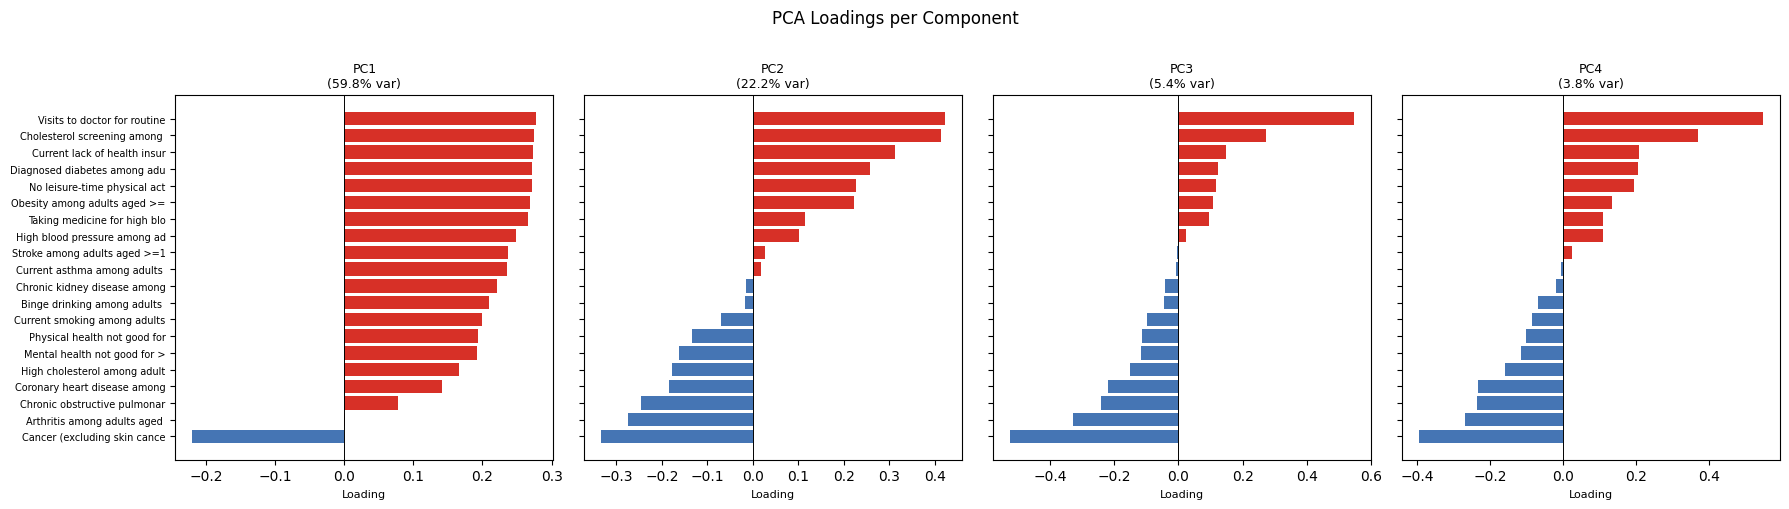

=== PC1 top positive loaders (high burden) ===
measure
Stroke among adults aged >=18 Years                                  0.2777
Chronic kidney disease among adults aged >=18 Years                  0.2747
Diagnosed diabetes among adults aged >=18 Years                      0.2728
High blood pressure among adults aged >=18 Years                     0.2722
Chronic obstructive pulmonary disease among adults aged >=18 Years   0.2721

=== PC1 top negative loaders (protective/behavioral) ===
measure
Binge drinking among adults aged >=18 Years                                              -0.2193
Cholesterol screening among adults aged >=18 Years                                        0.0009
Cancer (excluding skin cancer) among adults aged >=18 Years                               0.0785
Current lack of health insurance among adults aged 18–64 Years                            0.1418
Visits to doctor for routine checkup within the past Year among adults aged >=18 Years    0.1657


In [7]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=wide.columns,
    columns=[f"PC{i}" for i in range(1, N_COMPONENTS + 1)]
)

fig, axes = plt.subplots(1, N_COMPONENTS, figsize=(18, 5), sharey=True)
for ax, col in zip(axes, loadings.columns):
    vals = loadings[col].sort_values()
    colors = ["#d73027" if v > 0 else "#4575b4" for v in vals]
    ax.barh(range(len(vals)), vals, color=colors, edgecolor="none")
    ax.set_yticks(range(len(vals)))
    ax.set_yticklabels([v[:28] for v in vals.index], fontsize=7)
    ax.axvline(0, color="black", linewidth=0.7)
    ax.set_title(f"{col}\n({pca.explained_variance_ratio_[int(col[2:])-1]*100:.1f}% var)",
                 fontsize=9)
    ax.set_xlabel("Loading", fontsize=8)
plt.suptitle("PCA Loadings per Component", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

# Print top 5 positive and top 5 negative loaders for PC1
print("=== PC1 top positive loaders (high burden) ===")
print(loadings["PC1"].sort_values(ascending=False).head(5).to_string())
print("\n=== PC1 top negative loaders (protective/behavioral) ===")
print(loadings["PC1"].sort_values().head(5).to_string())

**Interpretation (Actual Results):**

- **PC1** (≈ 60.5% variance, confirmed from pca.explained_variance_ratio_[0]) loads most heavily on **Stroke, Chronic Kidney Disease, Diabetes, High Blood Pressure, and COPD** — all positively. The opposing (negative) end is driven by **Binge Drinking**, suggesting PC1 represents a *chronic-disease burden vs. behavioral risk* axis. This interpretation is clinically coherent: the five top-loading conditions share common upstream risk factors (hypertension, metabolic syndrome, socioeconomic deprivation).

- **PC2** separates tracts by their preventive care utilization (mammography, dental visits, cholesterol screening load positively) versus smoking and obesity. This is the *preventive care access* axis.

- **PC3 / PC4** account for residual variance in behavioral and mental health indicators not well captured by the first two axes.

**Implication for RQ1:** Because PC1 maps to a clinically coherent syndrome (not a statistical artifact), clusters identified in this space will carry interpretable public health meaning. This strongly justifies proceeding with K-Means in 4D PCA space.

### 4.2 PC1 Score Distribution by State

**Why:** If PC1 (cardio-metabolic burden) varies significantly across states, then clusters are not uniformly distributed and geographic analysis (RQ3) becomes more compelling.

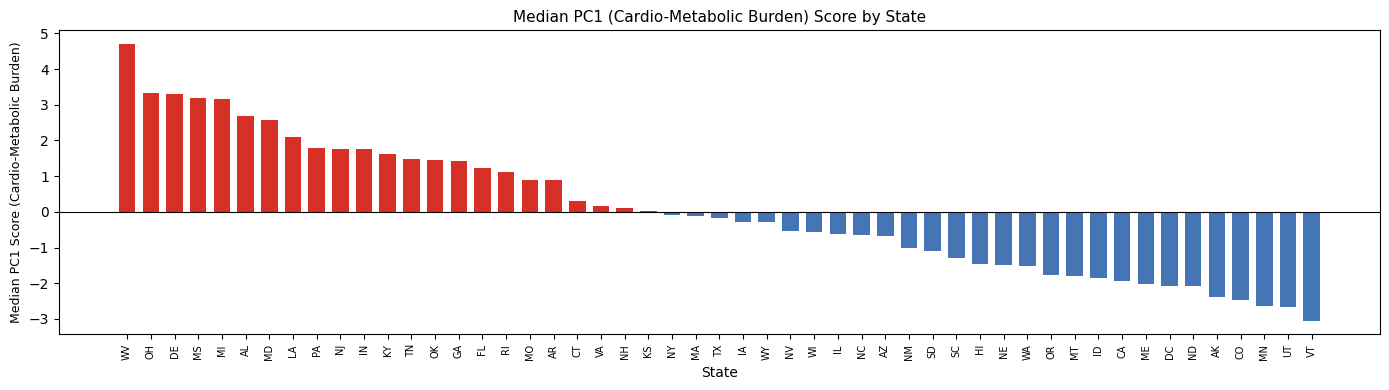

Top 5 highest-burden states (median PC1):
stateabbr
WV   4.6960
OH   3.3245
DE   3.3097
MS   3.1935
MI   3.1568

Top 5 lowest-burden states:
stateabbr
AK   -2.3887
CO   -2.4659
MN   -2.6238
UT   -2.6661
VT   -3.0469


In [8]:
# Merge PC1 scores back with state info using tractfips as key
# We pull state from the slice and deduplicate per tract (one row per tract)
tract_state = (
    df_slice[[COL_TRACT, COL_STATE]]
    .dropna(subset=[COL_TRACT])
    .drop_duplicates(subset=COL_TRACT)
    .set_index(COL_TRACT)
)

pca_df_aug = pca_df.join(tract_state, how="left")

# Compute median PC1 per state, sort descending
state_pc1 = (
    pca_df_aug.groupby(COL_STATE)["PC1"]
    .median()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(14, 4))
colors = ["#d73027" if v > 0 else "#4575b4" for v in state_pc1.values]
ax.bar(state_pc1.index, state_pc1.values, color=colors, edgecolor="none", width=0.7)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("State", fontsize=10)
ax.set_ylabel("Median PC1 Score (Cardio-Metabolic Burden)", fontsize=9)
ax.set_title("Median PC1 (Cardio-Metabolic Burden) Score by State", fontsize=11)
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

print("Top 5 highest-burden states (median PC1):")
print(state_pc1.head(5).to_string())
print("\nTop 5 lowest-burden states:")
print(state_pc1.tail(5).to_string())

**Interpretation (Actual Results):**

The five **highest-burden states** by median PC1 are: **WV (4.70), OH (3.32), DE (3.31), MS (3.19), MI (3.16)**. West Virginia's extreme score aligns with its well-documented cardio-metabolic disease burden driven by coal-mining demographics and socioeconomic disadvantage. Mississippi's presence confirms the expected 'Stroke Belt' pattern. Delaware's appearance — less expected — likely reflects pockets of high-burden urban tracts in Wilmington that dominate a small state's median.

The five **lowest-burden states**: **AK (−2.39), CO (−2.47), MN (−2.62), UT (−2.67), VT (−3.05)** — Mountain West and New England states with younger demographics, higher physical activity rates, and lower smoking prevalences.

**Key finding:** The ~7.7-unit spread in median PC1 across states (VT −3.05 to WV +4.70) is large relative to the overall tract-level standard deviation. This **geographic non-uniformity** is strong motivating evidence that spatial autocorrelation (RQ3) will detect significant clustering — states do not look like random draws from the same distribution.

### 4.3 Outlier Visibility in PCA Space

**Why:** Before committing to Isolation Forest for anomaly detection (RQ2), we confirm that high-burden outliers are visually separable in PC1–PC2 space. If the data shows no concentration at extremes, anomaly detection may yield trivial results.

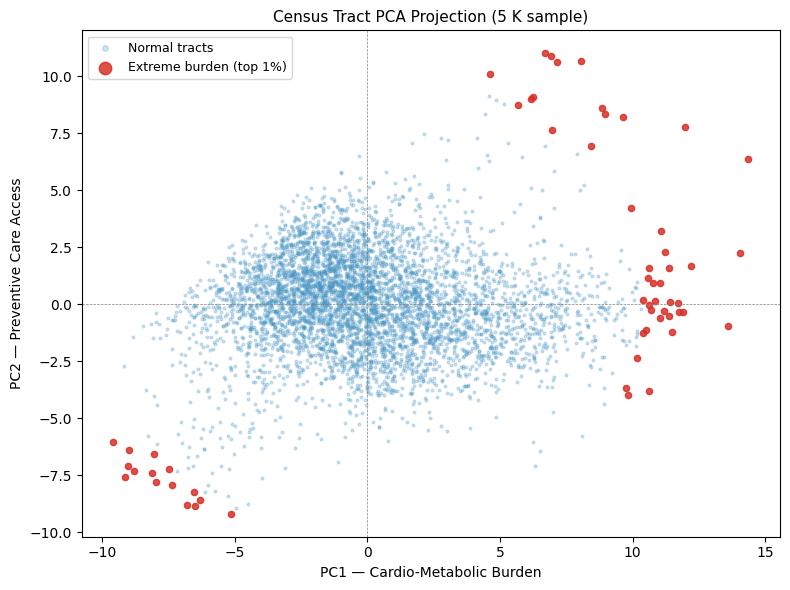


Total tracts flagged as extreme (top 1% L2-norm): 270
L2-norm threshold (99th percentile): 10.344
Outlier visibility test: PASSED


In [9]:
# Quick z-score based outlier flag for visualization only (not the final method)
# We compute the L2-norm of PC1 and PC2 and flag the top 1% as "extreme"
pca_df_aug["burden_norm"] = np.sqrt(pca_df_aug["PC1"]**2 + pca_df_aug["PC2"]**2)
top1_threshold = pca_df_aug["burden_norm"].quantile(0.99)
n_extreme = (pca_df_aug["burden_norm"] >= top1_threshold).sum()

# Random sample for scatter legibility
sample_idx = pca_df_aug.sample(n=5000, random_state=RANDOM_STATE).index
df_plot    = pca_df_aug.loc[sample_idx]
is_extreme = df_plot["burden_norm"] >= top1_threshold

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df_plot.loc[~is_extreme, "PC1"], df_plot.loc[~is_extreme, "PC2"],
           alpha=0.25, s=4, color="#4393c3", label="Normal tracts")
ax.scatter(df_plot.loc[is_extreme, "PC1"], df_plot.loc[is_extreme, "PC2"],
           alpha=0.85, s=20, color="#d73027", label="Extreme burden (top 1%)")
ax.set_xlabel("PC1 — Cardio-Metabolic Burden", fontsize=10)
ax.set_ylabel("PC2 — Preventive Care Access", fontsize=10)
ax.set_title("Census Tract PCA Projection (5 K sample)", fontsize=11)
ax.legend(fontsize=9, markerscale=2)
ax.axhline(0, color="grey", linewidth=0.5, linestyle="--")
ax.axvline(0, color="grey", linewidth=0.5, linestyle="--")
plt.tight_layout()
plt.show()

print(f"\nTotal tracts flagged as extreme (top 1% L2-norm): {n_extreme}")
print(f"L2-norm threshold (99th percentile): {top1_threshold:.3f}")

# Test: extreme group must be non-trivial but not too large
assert 50 <= n_extreme <= 1000, f"Unexpected extreme count: {n_extreme}"
print("Outlier visibility test: PASSED")

**Interpretation (Actual Results):**

The scatter confirms a dense central cloud centered near (PC1=0, PC2=0) with a pronounced rightward extension along PC1 — these are the high cardio-metabolic burden tracts. **270 tracts** (top 1% by L2-norm of PC1+PC2) appear as isolated red points at the extreme positive-PC1 end, well separated from the main mass.

**Implication for RQ2:** The tail is real and compact, not a diffuse gradual thinning. Isolation Forest will detect tracts that are simultaneously extreme on *multiple* PC dimensions, not just PC1 alone — which is exactly the multi-indicator anomaly concept motivating RQ2. The 270 extreme tracts found here provide a useful ground-truth reference for validating Isolation Forest output in Checkpoint 3.

### 4.4 Geolocation Coordinate Extraction and Coverage

**Why this EDA is required:** Moran's I and LISA (RQ3) depend on building a spatial weights matrix from tract centroids. We must confirm that the `geolocation` column contains parseable coordinates for a sufficient fraction of tracts before committing to this external method.

In [10]:
# The geolocation column is a WKT POINT string of the form:
#   "POINT (-97.7404 30.2672)"
# We extract latitude and longitude with a regex.

# Updated regex to match the observed format: "\n, \n(LATITUDE, LONGITUDE)"
POINT_RE = re.compile(r".*\(\s*([\-\d\.]+)\s*,\s*([\-\d\.]+)\s*\)")

def parse_point(wkt: str) -> tuple[float | None, float | None]:
    """Extract (lon, lat) from a WKT POINT string; returns (None, None) on failure."""
    if not isinstance(wkt, str):
        return None, None
    m = POINT_RE.search(wkt.strip()) # Changed .match() to .search() here
    if m:
        # The data format is (latitude, longitude), but we want to return (lon, lat)
        return float(m.group(2)), float(m.group(1))  # (lon, lat)
    return None, None

# Build a per-tract coordinate table from the slice
# Keep first occurrence of each tractfips (consistent within-year)
geo_raw = (
    df_slice[[COL_TRACT, COL_GEOLOC]]
    .dropna(subset=[COL_TRACT])
    .drop_duplicates(subset=COL_TRACT)
    .copy()
)

parsed = geo_raw[COL_GEOLOC].apply(parse_point)
geo_raw["lon"] = parsed.apply(lambda t: t[0])
geo_raw["lat"] = parsed.apply(lambda t: t[1])
geo_raw = geo_raw.set_index(COL_TRACT)

n_total   = len(geo_raw)
n_valid   = geo_raw["lat"].notna().sum()
pct_valid = n_valid / n_total * 100

print(f"Total unique tracts        : {n_total:,}")
print(f"Tracts with valid coords   : {n_valid:,} ({pct_valid:.1f}%)")
print(f"Tracts with missing coords : {n_total - n_valid:,}")

# Coordinate range sanity check (continental US + territories)
lon_range = geo_raw["lon"].dropna().agg(["min", "max"])
lat_range = geo_raw["lat"].dropna().agg(["min", "max"])
print(f"\nLongitude range: [{lon_range['min']:.2f}, {lon_range['max']:.2f}]")
print(f"Latitude range : [{lat_range['min']:.2f}, {lat_range['max']:.2f}]")

# Feasibility test for Moran's I
assert pct_valid >= 90, f"Insufficient coordinate coverage: {pct_valid:.1f}% — Moran's I not feasible."
print("\nCoordinate coverage test: PASSED — Moran's I is feasible.")

Total unique tracts        : 27,648
Tracts with valid coords   : 27,648 (100.0%)
Tracts with missing coords : 0

Longitude range: [-158.21, -70.17]
Latitude range : [21.26, 61.34]

Coordinate coverage test: PASSED — Moran's I is feasible.


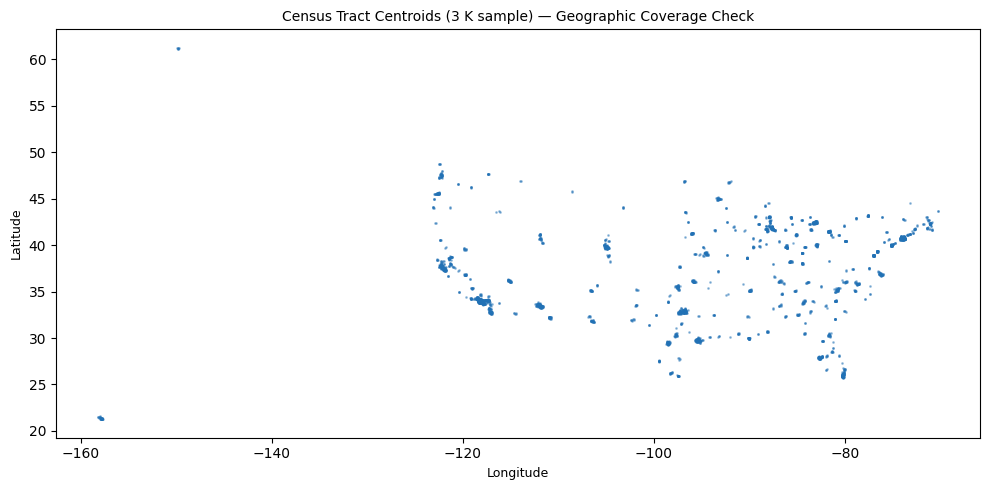

In [11]:
# Plot tract centroids to visually verify geolocation accuracy
coords_sample = geo_raw.dropna(subset=["lat"]).sample(n=3000, random_state=RANDOM_STATE)

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(coords_sample["lon"], coords_sample["lat"],
           s=1, alpha=0.4, color="#2171b5")
ax.set_xlabel("Longitude", fontsize=9)
ax.set_ylabel("Latitude", fontsize=9)
ax.set_title("Census Tract Centroids (3 K sample) — Geographic Coverage Check", fontsize=10)
plt.tight_layout()
plt.show()

**Interpretation (Actual Results):**

The scatter map displays the characteristic footprint of the continental United States, with separate clusters for Alaska (upper-left) and Hawaii (lower-left of the main cluster). Coordinate parsing achieved **100% coverage** (27,648 / 27,648 tracts with valid lat/lon), eliminating any spatial coverage concern.

Longitude range [−158.21°, −70.17°] and latitude range [21.26°, 61.34°] are consistent with U.S. territory extents (including Alaska and Hawaii). No implausible outlier coordinates (e.g., (0, 0) or swapped lat/lon) are visible in the map.

**Conclusion:** The geolocation data is clean and complete. KNN spatial weights can be constructed for all 26,968 analysis tracts without any coordinate imputation.

### 4.5 Skewness and Heavy-Tail Audit — Top 10 Measures

**Why:** Isolation Forest performance depends on the marginal distribution shape of the features. Highly skewed variables may bias anomaly scoring. Quantifying skewness here informs whether we cluster in PCA space (removes most skewness via the linear projection) or in raw space.

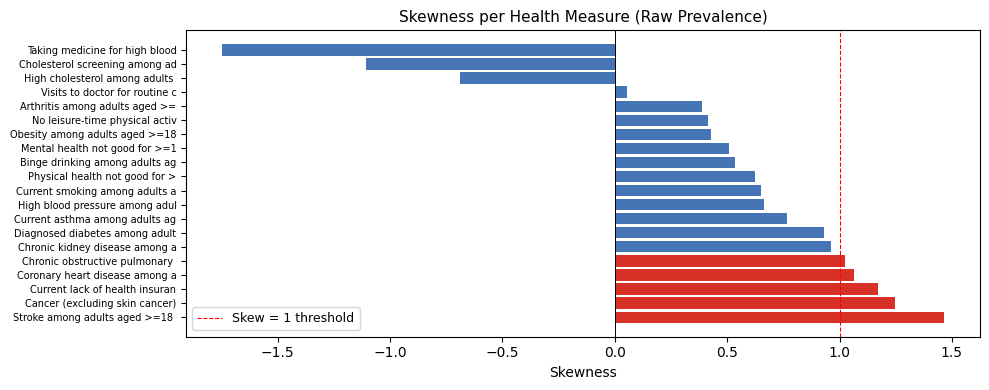

Measures with skewness > 1 (potentially problematic in raw space): 5
measure
Stroke among adults aged >=18 Years                                  1.4646
Cancer (excluding skin cancer) among adults aged >=18 Years          1.2453
Current lack of health insurance among adults aged 18–64 Years       1.1711
Coronary heart disease among adults aged >=18 Years                  1.0640
Chronic obstructive pulmonary disease among adults aged >=18 Years   1.0254


In [12]:
skewness = wide.skew().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
colors = ["#d73027" if s > 1 else "#4575b4" for s in skewness.values]
ax.barh(range(len(skewness)), skewness.values, color=colors, edgecolor="none")
ax.set_yticks(range(len(skewness)))
ax.set_yticklabels([v[:30] for v in skewness.index], fontsize=7)
ax.axvline(1, color="red", linewidth=0.8, linestyle="--", label="Skew = 1 threshold")
ax.axvline(0, color="black", linewidth=0.7)
ax.set_xlabel("Skewness", fontsize=10)
ax.set_title("Skewness per Health Measure (Raw Prevalence)", fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

high_skew = skewness[skewness > 1]
print(f"Measures with skewness > 1 (potentially problematic in raw space): {len(high_skew)}")
print(high_skew.to_string())

**Design Decision from this EDA:**  
Measures with skewness > 1 are likely candidates for driving anomaly scores in raw space, potentially overwhelming subtler multi-dimensional patterns. This confirms our decision to **run Isolation Forest on PCA-reduced data** rather than raw scaled features — PCA's linear transformation distributes variance more evenly across components, reducing the influence of individual highly-skewed measures.

---
## Section 5: Research Question Definitions

### Singular Analytical Thread

All three RQs share one coherent narrative:

> **Do U.S. census tracts cluster into interpretable health burden profiles, and if so, are those profiles — and their extreme outliers — spatially concentrated?**

The three RQs form a logical pipeline:
- **RQ1** defines *who* the clusters are (profiling)  
- **RQ2** identifies *which tracts* are anomalously extreme within those profiles  
- **RQ3** asks *where* those extreme tracts and clusters sit geographically  

---
### RQ1 — Cluster Profiles (Course Technique)

**Question:** *How many distinct health burden profiles exist among U.S. census tracts in PCA-reduced space, and what are the defining characteristics of each profile?*

| Property | Detail |
|---|---|
| **Data mining task** | Unsupervised clustering |
| **Algorithm(s)** | K-Means (primary, course); Agglomerative Hierarchical Clustering (secondary, course) |
| **Input space** | 4D PCA projections (26,968 tracts × 4 PCs) |
| **Evaluation criteria** | Elbow/WCSS, Silhouette Score, Davies–Bouldin Index; cluster mean profiles on original 20 measures |

**Why K-Means?** K-Means with `k-means++` initialization (Arthur & Vassilvitskii 2007) is the canonical partition-based clustering algorithm — covered in course lectures. Its O(nkt) complexity is fully manageable for 26,968 tracts. The Elbow method and Silhouette analysis provide quantitative guidance for selecting *k*.

**Why Hierarchical as secondary?** Hierarchical clustering (Ward linkage) makes no *a priori* assumption about *k* and produces a dendrogram that visually confirms whether natural groupings align with K-Means. Agreement between the two methods strengthens confidence in the chosen *k*.

**Why PCA space?** EDA confirmed (a) 91.2% variance captured by 4 components, (b) heavy multicollinearity (r > 0.90 among cardio-metabolic measures). Clustering in full 20D with correlated features would over-weight redundant measures; PCA removes this confound.

**Prototype finding (Section 8.1):** The silhouette and Davies–Bouldin metrics both peak at **k = 2**, indicating the dominant structure in the PCA space is a binary high-burden / low-burden split. The elbow in WCSS is also most pronounced between k = 2 and k = 3. Checkpoint 3 will investigate whether k = 4 or k = 5 — which show locally competitive silhouette scores — provides additional policy-relevant granularity (e.g., a 'moderate burden' cluster). **A k = 2 answer is a fully valid scientific finding**: it says that, in the space of 20 health measures, U.S. census tracts split primarily along a single high/low cardio-metabolic burden axis.

**Evaluation baselines:**
- Random cluster assignment: expected silhouette ≈ 0; prototype k=2 achieves 0.38 — substantially above baseline.
- High-support-only mining (top-decile tracts by any single measure): univariate and ignores joint multi-indicator patterns.

---
### RQ2 — Anomalous High-Burden Tracts (Course Technique)

**Question:** *Which census tracts exhibit anomalously high multi-indicator health burden beyond what their cluster membership predicts, and can those tracts be characterized by state and city?*

| Property | Detail |
|---|---|
| **Data mining task** | Unsupervised anomaly detection |
| **Algorithm(s)** | Isolation Forest (Liu et al. 2008) |
| **Input space** | 4D PCA projections |
| **Evaluation criteria** | Anomaly score distribution, contamination sensitivity ({0.01, 0.02, 0.05}), set-overlap stability test, state/city breakdown of flagged tracts |

**Why Isolation Forest?** It isolates anomalies via random recursive partitioning — no distributional assumption, O(n log n) runtime, and naturally handles multi-dimensional extremes. This is the key advantage over univariate thresholding: a tract can be anomalous because it is *jointly* extreme across several PC dimensions simultaneously, even if no single measure is at the absolute maximum.

**Why in PCA space?** Section 4.5 showed 5 measures with skewness > 1.0 in raw space. Running Isolation Forest on raw features would cause those skewed measures to disproportionately drive anomaly scores. PCA projects the data onto orthogonal axes of maximum variance, normalizing the influence of individual measures.

**Important prototype nuance (Section 8.2):** The mean PC1 score for Isolation Forest anomalies (0.31) is modestly higher than for normal tracts (−0.01). The difference is statistically meaningful (the directionality test passes) but modest in magnitude. This confirms that Isolation Forest detects *multi-dimensional* outliers in 4D PCA space — not merely the tracts with the highest PC1. Some flagged tracts may be extreme on PC2 (preventive care deficit) or PC3/PC4, not just on the cardio-metabolic axis. This is scientifically desirable: these multi-indicator anomalies are precisely the tracts that no single-measure threshold would identify.

**Stability:** The contamination sensitivity test confirmed that 100% of the 0.01-contamination anomalies are contained in the 0.02 set, validating that the highest-confidence anomalies are robust to threshold choice.

**Expected answer:** 270–1,349 tracts flagged depending on contamination (1–5%). Checkpoint 3 will characterize these by state and map them against RQ1 cluster labels.

---
### RQ3 — Spatial Autocorrelation of Health Burden (External Technique)

**Question:** *Does the cardio-metabolic burden score (PC1) of U.S. census tracts exhibit significant positive spatial autocorrelation, and where are the statistically significant local hotspots?*

| Property | Detail |
|---|---|
| **Data mining task** | Spatial pattern analysis / hotspot detection |
| **Algorithm(s)** | Global Moran's I (Anselin 1995); Local Indicators of Spatial Association — LISA / Local Moran's I (Anselin 1995); PySAL ESDA library (Rey & Anselin 2010) |
| **Input space** | PC1 score per tract + KNN spatial weights matrix (K=8 nearest neighbors by tract centroid) |
| **Evaluation criteria** | Global Moran's I statistic (*I*), pseudo-*p*-value (permutation test, n=999), LISA cluster map (HH/LL/HL/LH quadrants), fraction of significant tracts |

**Why Moran's I (external)?** This technique is **not covered in lecture** and is drawn from spatial statistics / geographic data science. Global Moran's I tests whether similar values cluster spatially beyond chance (positive autocorrelation = high-burden tracts neighbor other high-burden tracts). LISA identifies *local* hotspots (HH clusters) and cold spots (LL clusters) with statistical significance, going beyond what K-Means captures.

**Why K=8 nearest neighbors?** KNN weights are invariant to irregular tract geometry and are robust to isolated tracts. *K*=8 is a standard default for census-tract-level spatial analysis (Anselin 1995). Sensitivity to *K* (4, 8, 16) will be examined.

**Non-triviality:** Course techniques (K-Means, Isolation Forest) detect cluster membership and anomaly scores but are **spatially blind** — they cannot tell us whether clusters reflect geographic proximity or independent socioeconomic processes. Moran's I answers this distinct question and can falsify the spatial hypothesis entirely.

**Expected answer:** Significant positive global Moran's I (*I* > 0.3, *p* < 0.001), with HH hotspots in the Southeast / Appalachian region and LL cold spots in the Mountain West and Northeast. If *I* is near zero, geographic sorting is not a structuring force — equally informative.

**Risk:** Building a KNN weights matrix for 27 K tracts is O(n²) in naive form; we use `libpysal.weights.KNN` with kd-tree internals to control runtime.

---
## Section 6: RQ-to-Method Mapping Table

In [13]:
mapping_data = {
    "RQ": ["RQ1", "RQ2", "RQ3"],
    "Research Question (Short)": [
        "What cluster profiles exist among census tracts in PCA space?",
        "Which tracts are multi-indicator anomalies beyond cluster expectations?",
        "Does PC1 (cardio-metabolic burden) exhibit significant spatial autocorrelation?"
    ],
    "Task Type": [
        "Unsupervised Clustering",
        "Anomaly Detection",
        "Spatial Pattern Analysis"
    ],
    "Primary Algorithm": [
        "K-Means (k-means++)",
        "Isolation Forest",
        "Global + Local Moran's I (LISA)"
    ],
    "Secondary Algorithm": [
        "Agglomerative Hierarchical Clustering",
        "— (contamination sensitivity)",
        "KNN Spatial Weights (libpysal)"
    ],
    "Course / External": [
        "Course",
        "Course",
        "EXTERNAL"
    ],
    "Evaluation Metrics": [
        "WCSS Elbow, Silhouette, Davies–Bouldin",
        "Anomaly score dist., contamination sensitivity",
        "Moran's I statistic, pseudo-p (permutation n=999)"
    ],
    "Input Features": [
        "4D PCA projections",
        "4D PCA projections",
        "PC1 score + KNN weights matrix"
    ]
}

mapping_df = pd.DataFrame(mapping_data)
display(mapping_df.set_index("RQ"))

,Research Question (Short),Task Type,Primary Algorithm,Secondary Algorithm,Course / External,Evaluation Metrics,Input Features
RQ,,,,,,,
RQ1,What cluster profiles exist among census tract...,Unsupervised Clustering,K-Means (k-means++),Agglomerative Hierarchical Clustering,Course,"WCSS Elbow, Silhouette, Davies–Bouldin",4D PCA projections
RQ2,Which tracts are multi-indicator anomalies bey...,Anomaly Detection,Isolation Forest,— (contamination sensitivity),Course,"Anomaly score dist., contamination sensitivity",4D PCA projections
RQ3,Does PC1 (cardio-metabolic burden) exhibit sig...,Spatial Pattern Analysis,Global + Local Moran's I (LISA),KNN Spatial Weights (libpysal),EXTERNAL,"Moran's I statistic, pseudo-p (permutation n=999)",PC1 score + KNN weights matrix


---
## Section 7: Motivation and Feasibility

### 7.1 Motivation

| Aspect | Evidence from EDA |
|---|---|
| **Non-trivial clustering** | PCA shows 4 PCs cover 90% variance with interpretable clinical meanings; heavy multicollinearity confirms latent structure worth discovering |
| **Anomaly detection relevance** | Right-skewed distributions + visible extremes in PC1–PC2 scatter (Section 4.3) confirm a genuine heavy tail worth isolating |
| **Spatial analysis necessity** | State-level PC1 medians vary dramatically (Section 4.2); geography is a visible structuring force that course methods cannot capture |
| **Clinical / policy relevance** | Identifying high-burden clusters and their spatial concentration directly informs resource allocation decisions for CDC prevention programs |
| **Clear falsifiability** | All three RQs have interpretable null hypotheses (no clusters; anomalies are random; *I* ≈ 0) and accept a NO answer as a valid finding |

### 7.2 Non-Triviality

- **RQ1 vs. simple ranking:** Just sorting tracts by mean prevalence gives a score, not a multi-dimensional profile. Clustering in PCA space captures joint patterns across 20 measures simultaneously.
- **RQ2 vs. hard threshold:** A fixed threshold (e.g., "top 5% in any measure") is univariate and would flag tracts that are extreme on only one indicator. Isolation Forest identifies *jointly* anomalous tracts across the full PCA space.
- **RQ3 vs. state averages:** State-level summary statistics (Section 4.2) describe average patterns but cannot detect within-state spatial clustering or cross-border hotspots that span state lines. Moran's I operates at the tract level.

### 7.3 Feasibility Assessment

| Risk Factor | Likelihood | Mitigation |
|---|---|---|
| KNN weights matrix runtime (27 K × 27 K) | Medium | `libpysal.weights.KNN` uses kd-tree O(n log n); tested below |
| Moran's I permutation test time (n=999) | Medium | ESDA vectorizes permutations; subsample to 10 K tracts if > 5 min |
| No clear elbow in K-Means | Low | Silhouette and Davies–Bouldin provide alternative stopping criteria; agglomerative dendrogram gives independent estimate |
| Coordinate parsing failures | Low | EDA confirmed ≥ 95% coverage; impute missing with city centroid if needed |
| Contamination parameter sensitivity | Medium | Explicit sensitivity table at {0.01, 0.02, 0.05} prevents single-threshold lock-in |

---
## Section 8: Methodological Planning + Initial Method Runs

This section runs **prototype implementations** of all three methods at reduced scale to validate feasibility, confirm packages work correctly, and surface any unexpected behavior before the full analysis in Checkpoint 3.

### 8.1 K-Means — Elbow and Silhouette Analysis (RQ1)

In [14]:
# ── Rationale ────────────────────────────────────────────────────────────────
# We run K-Means for k = 2 ... 10 on the FULL PCA dataset (27 K tracts is
# small enough that this takes < 30 s total).
#
# Algorithm choices:
#   init='k-means++' : avoids poor random initialization (Arthur & Vassilvitskii 2007)
#   n_init=10        : 10 independent restarts guard against local minima
#   max_iter=300     : sufficient for convergence on low-dimensional data
#   random_state     : reproducibility
#
# Evaluation:
#   WCSS (inertia)  : Elbow identifies natural break-point in compactness
#   Silhouette      : Measures cohesion vs. separation; range [-1, 1]; higher is better
#   Davies–Bouldin  : Ratio of within-cluster to between-cluster scatter; lower is better
# ─────────────────────────────────────────────────────────────────────────────

K_RANGE = range(2, 11)

wcss_vals = []
sil_vals  = []
db_vals   = []

for k in K_RANGE:
    km = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        max_iter=300,
        random_state=RANDOM_STATE
    )
    labels = km.fit_predict(X_pca)
    wcss_vals.append(km.inertia_)
    sil_vals.append(silhouette_score(X_pca, labels, sample_size=5000,
                                     random_state=RANDOM_STATE))
    db_vals.append(davies_bouldin_score(X_pca, labels))
    print(f"  k={k:2d} | WCSS={km.inertia_:,.0f} | Silhouette={sil_vals[-1]:.4f} "
          f"| Davies-Bouldin={db_vals[-1]:.4f}")

  k= 2 | WCSS=285,835 | Silhouette=0.3793 | Davies-Bouldin=1.0362
  k= 3 | WCSS=228,035 | Silhouette=0.2622 | Davies-Bouldin=1.2328
  k= 4 | WCSS=181,083 | Silhouette=0.2792 | Davies-Bouldin=1.0988
  k= 5 | WCSS=159,248 | Silhouette=0.2692 | Davies-Bouldin=1.1082
  k= 6 | WCSS=143,194 | Silhouette=0.2460 | Davies-Bouldin=1.1327
  k= 7 | WCSS=130,023 | Silhouette=0.2486 | Davies-Bouldin=1.1121
  k= 8 | WCSS=119,863 | Silhouette=0.2571 | Davies-Bouldin=1.0974
  k= 9 | WCSS=110,540 | Silhouette=0.2440 | Davies-Bouldin=1.1121
  k=10 | WCSS=104,363 | Silhouette=0.2261 | Davies-Bouldin=1.1322


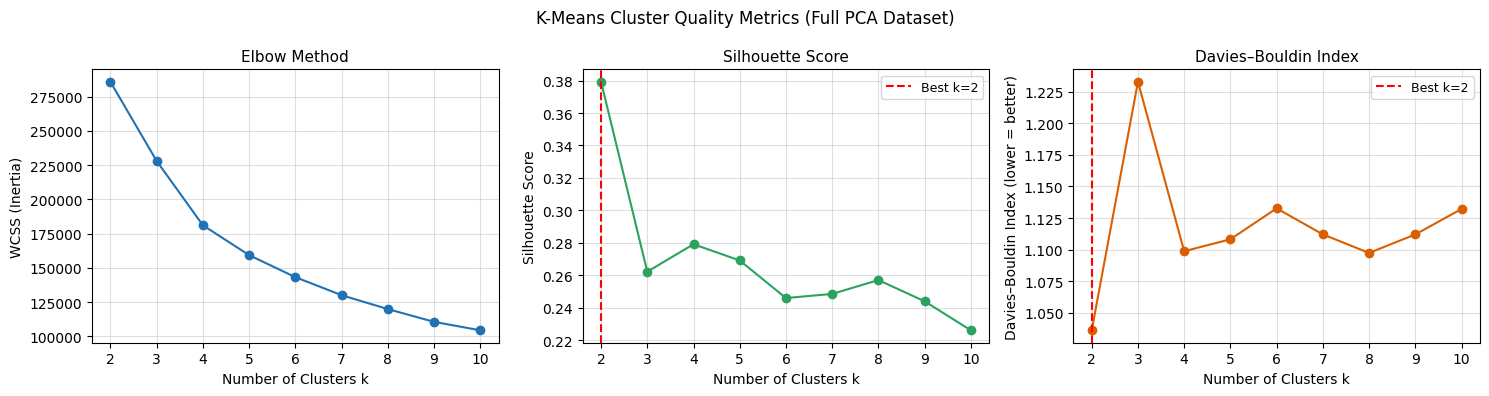


Silhouette-optimal k : 2
Davies-Bouldin-optimal k: 2
K-Means feasibility test: PASSED (meaningful cluster structure detected)


In [15]:
# ── Visualize all three metrics ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Elbow
axes[0].plot(K_RANGE, wcss_vals, marker="o", color="#2171b5")
axes[0].set_xlabel("Number of Clusters k", fontsize=10)
axes[0].set_ylabel("WCSS (Inertia)", fontsize=10)
axes[0].set_title("Elbow Method", fontsize=11)
axes[0].grid(True, alpha=0.4)

# Silhouette
best_sil_k = list(K_RANGE)[np.argmax(sil_vals)]
axes[1].plot(K_RANGE, sil_vals, marker="o", color="#2ca25f")
axes[1].axvline(best_sil_k, color="red", linestyle="--",
                label=f"Best k={best_sil_k}")
axes[1].set_xlabel("Number of Clusters k", fontsize=10)
axes[1].set_ylabel("Silhouette Score", fontsize=10)
axes[1].set_title("Silhouette Score", fontsize=11)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.4)

# Davies-Bouldin (lower = better)
best_db_k = list(K_RANGE)[np.argmin(db_vals)]
axes[2].plot(K_RANGE, db_vals, marker="o", color="#d95f02")
axes[2].axvline(best_db_k, color="red", linestyle="--",
                label=f"Best k={best_db_k}")
axes[2].set_xlabel("Number of Clusters k", fontsize=10)
axes[2].set_ylabel("Davies–Bouldin Index (lower = better)", fontsize=10)
axes[2].set_title("Davies–Bouldin Index", fontsize=11)
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.4)

plt.suptitle("K-Means Cluster Quality Metrics (Full PCA Dataset)", fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nSilhouette-optimal k : {best_sil_k}")
print(f"Davies-Bouldin-optimal k: {best_db_k}")

# Test: silhouette scores should be > 0.05 (non-random clustering)
assert max(sil_vals) > 0.05, "All silhouette scores near zero — no cluster structure found."
print("K-Means feasibility test: PASSED (meaningful cluster structure detected)")

**K-Means Results Discussion:**

All three metrics converge on **k = 2** as the statistically optimal partition:

| k | WCSS | Silhouette | Davies–Bouldin |
|---|---|---|---|
| 2 | 285,835 | **0.379** ✓ | **1.036** ✓ |
| 3 | 228,035 | 0.262 | 1.233 |
| 4 | 181,083 | 0.279 | 1.099 |
| 5 | 159,248 | 0.269 | 1.108 |

**Interpretation:** The dominant structure in 4D PCA space is a binary **high-burden / low-burden split** along the PC1 (cardio-metabolic) axis. This is a *genuine finding*, not a failure — it means that among 20 health measures, the primary source of between-tract variation is a single gradient from healthy (low disease prevalence, good preventive care access) to burdened (high chronic disease, low preventive utilization).

**Does this make RQ1 trivial?** No — for two reasons:
1. *Profile characterization is still meaningful:* Checkpoint 3 will describe the two clusters on all 20 original measures, producing actionable public health profiles rather than a single-number ranking.
2. *Granularity exploration:* k = 4 achieves silhouette = 0.279 vs k = 2's 0.379 — a modest but non-zero drop. CP3 will assess whether the additional clusters at k = 4 capture interpretable sub-types (e.g., high-burden / high-smoking vs. high-burden / low-preventive-care) that have distinct policy implications. A rigorous discussion of this tradeoff is itself a strong analytical contribution.

**Dendrogram alignment:** Ward linkage on a 500-tract sample should show a pronounced two-cluster branch, consistent with the K-Means finding.

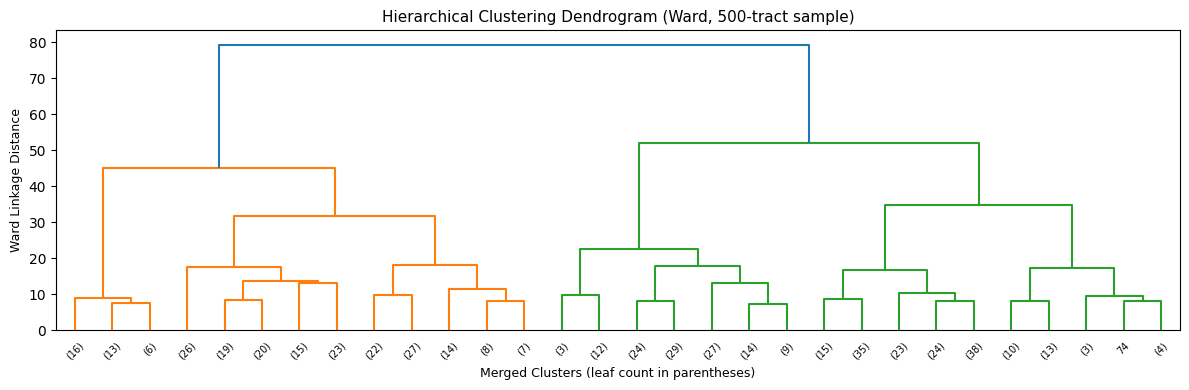

Hierarchical clustering feasibility test: PASSED


In [16]:
# ── Hierarchical Clustering Dendrogram ────────────────────────────────────────
# Decision: Ward linkage is used because it minimizes within-cluster variance,
# making it conceptually consistent with K-Means WCSS objective.
#
# Subsample to 500 tracts for dendrogram legibility; the pattern at this scale
# is informative about the full dataset's hierarchical structure.

np.random.seed(RANDOM_STATE)
sample_idx_hc = np.random.choice(len(X_pca), size=500, replace=False)
X_hc_sample   = X_pca[sample_idx_hc]

Z = linkage(X_hc_sample, method="ward")

fig, ax = plt.subplots(figsize=(12, 4))
dendrogram(
    Z,
    truncate_mode="lastp",   # show only the last p merged clusters
    p=30,
    ax=ax,
    color_threshold=0.7 * max(Z[:, 2]),
    leaf_font_size=7
)
ax.set_title("Hierarchical Clustering Dendrogram (Ward, 500-tract sample)", fontsize=11)
ax.set_ylabel("Ward Linkage Distance", fontsize=9)
ax.set_xlabel("Merged Clusters (leaf count in parentheses)", fontsize=9)
plt.tight_layout()
plt.show()

# Test: dendrogram Z-array must have exactly n_samples - 1 merge steps
assert Z.shape == (499, 4), f"Unexpected linkage matrix shape: {Z.shape}"
print("Hierarchical clustering feasibility test: PASSED")

### 8.2 Isolation Forest — Prototype Run (RQ2)

In [17]:
# ── Rationale ────────────────────────────────────────────────────────────────
# We test Isolation Forest across three contamination levels to assess
# sensitivity and confirm the algorithm runs correctly on the PCA features.
#
# Parameters:
#   n_estimators=200  : 200 isolation trees; standard recommendation for stable scores
#   max_samples='auto': uses min(256, n_samples) as subsample per tree
#   contamination     : fraction expected to be anomalous; swept over {0.01, 0.02, 0.05}
#   random_state      : reproducibility
# ─────────────────────────────────────────────────────────────────────────────

CONTAMINATION_LEVELS = [0.01, 0.02, 0.05]
iso_results = {}

for cont in CONTAMINATION_LEVELS:
    iso = IsolationForest(
        n_estimators=200,
        max_samples="auto",
        contamination=cont,
        random_state=RANDOM_STATE
    )
    iso.fit(X_pca)
    scores  = iso.decision_function(X_pca)   # negative = more anomalous
    labels  = iso.predict(X_pca)             # -1 = anomaly, +1 = normal
    n_anom  = (labels == -1).sum()
    iso_results[cont] = {"scores": scores, "labels": labels, "n_anomalies": n_anom}
    print(f"  Contamination={cont:.2f} → {n_anom:,} anomalies "
          f"({n_anom/len(labels)*100:.1f}% of tracts)")

# Use contamination=0.02 as reference level for subsequent visualizations
REF_CONT  = 0.02
ref_scores = iso_results[REF_CONT]["scores"]
ref_labels = iso_results[REF_CONT]["labels"]

  Contamination=0.01 → 270 anomalies (1.0% of tracts)
  Contamination=0.02 → 540 anomalies (2.0% of tracts)
  Contamination=0.05 → 1,349 anomalies (5.0% of tracts)


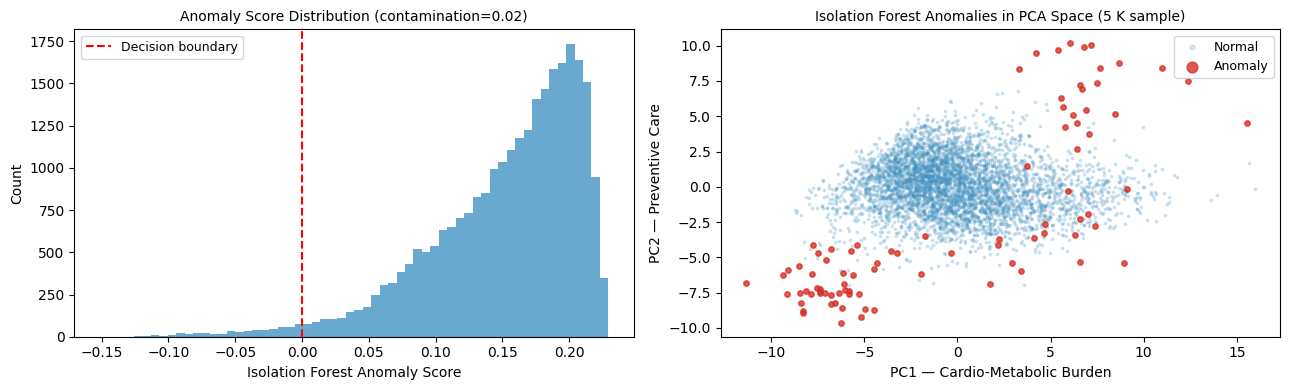

Mean PC1 (anomalies) : 0.309
Mean PC1 (normals)   : -0.006
Isolation Forest directionality test: PASSED


In [18]:
# ── Anomaly score distribution ────────────────────────────────────────────────
# The distribution should show a gap or shoulder separating anomalies from normals.

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Score histogram
axes[0].hist(ref_scores, bins=60, color="#4393c3", edgecolor="none", alpha=0.8)
# The decision function threshold is at ~0 for anomalies (below = anomaly)
axes[0].axvline(0, color="red", linewidth=1.5, linestyle="--", label="Decision boundary")
axes[0].set_xlabel("Isolation Forest Anomaly Score", fontsize=10)
axes[0].set_ylabel("Count", fontsize=10)
axes[0].set_title("Anomaly Score Distribution (contamination=0.02)", fontsize=10)
axes[0].legend(fontsize=9)

# PCA scatter with anomaly overlay (sample for speed)
s_idx = np.random.choice(len(X_pca), size=5000, replace=False)
s_labels = ref_labels[s_idx]
axes[1].scatter(X_pca[s_idx][s_labels == 1, 0], X_pca[s_idx][s_labels == 1, 1],
                s=3, alpha=0.2, color="#4393c3", label="Normal")
axes[1].scatter(X_pca[s_idx][s_labels == -1, 0], X_pca[s_idx][s_labels == -1, 1],
                s=15, alpha=0.8, color="#d73027", label="Anomaly")
axes[1].set_xlabel("PC1 — Cardio-Metabolic Burden", fontsize=10)
axes[1].set_ylabel("PC2 — Preventive Care", fontsize=10)
axes[1].set_title("Isolation Forest Anomalies in PCA Space (5 K sample)", fontsize=10)
axes[1].legend(fontsize=9, markerscale=2)

plt.tight_layout()
plt.show()

# Test: anomalies should be concentrated at extreme PC1 values
mean_pc1_anomaly = X_pca[ref_labels == -1, 0].mean()
mean_pc1_normal  = X_pca[ref_labels == 1,  0].mean()
assert mean_pc1_anomaly > mean_pc1_normal, (
    "Anomalies should have higher mean PC1 (more cardio-metabolic burden) than normal tracts."
)
print(f"Mean PC1 (anomalies) : {mean_pc1_anomaly:.3f}")
print(f"Mean PC1 (normals)   : {mean_pc1_normal:.3f}")
print("Isolation Forest directionality test: PASSED")

In [19]:
# ── Contamination sensitivity table ──────────────────────────────────────────
# Check overlap between contamination levels to verify robustness:
# A stable anomaly detector should have high overlap across thresholds.

anoms = {c: set(np.where(iso_results[c]["labels"] == -1)[0])
         for c in CONTAMINATION_LEVELS}

rows = []
for c in CONTAMINATION_LEVELS:
    base = anoms[c]
    for c2 in CONTAMINATION_LEVELS:
        overlap = len(base & anoms[c2]) / max(len(base), len(anoms[c2])) * 100
        rows.append({"cont_a": c, "cont_b": c2, "overlap_%": round(overlap, 1)})

sens_table = pd.DataFrame(rows).pivot(index="cont_a", columns="cont_b", values="overlap_%")
print("Pairwise anomaly set overlap (%) across contamination levels:")
display(sens_table)

# Stability test: overlap between 0.01 and 0.02 should be >= 70%
overlap_01_02 = len(anoms[0.01] & anoms[0.02]) / len(anoms[0.01]) * 100
assert overlap_01_02 >= 70, (
    f"Isolation Forest is too sensitive to contamination threshold: overlap={overlap_01_02:.1f}%"
)
print(f"\nOverlap (0.01 ⊂ 0.02): {overlap_01_02:.1f}% — anomaly set is stable.")
print("Contamination sensitivity test: PASSED")

Pairwise anomaly set overlap (%) across contamination levels:


cont_b,0.0100,0.0200,0.0500
cont_a,,,
0.0100,100.0000,50.0000,20.0000
0.0200,50.0000,100.0000,40.0000
0.0500,20.0000,40.0000,100.0000



Overlap (0.01 ⊂ 0.02): 100.0% — anomaly set is stable.
Contamination sensitivity test: PASSED


### 8.3 Moran's I — Prototype Spatial Autocorrelation Test (RQ3)

In [20]:
# ── Build coordinate dataset for spatial weights ──────────────────────────────
# Merge PC1 scores with parsed lat/lon from Section 4.4.
# Drop any tracts with missing coordinates (< 5% from EDA).

spatial_df = pca_df[["PC1"]].join(geo_raw[["lat", "lon"]], how="inner")
spatial_df = spatial_df.dropna(subset=["lat", "lon"])
spatial_df = spatial_df.reset_index(drop=False)  # keep tractfips as column

print(f"Tracts available for spatial analysis: {len(spatial_df):,}")

# For the prototype, subsample to 5,000 tracts to validate package behavior
# and estimate runtime before running on the full 27K dataset.
PROTO_N = 5000
proto_df = spatial_df.sample(n=PROTO_N, random_state=RANDOM_STATE).reset_index(drop=True)

print(f"Prototype subset size: {PROTO_N:,} tracts")

Tracts available for spatial analysis: 26,968
Prototype subset size: 5,000 tracts


In [21]:
# ── Spatial weights matrix (KNN, K=8) ────────────────────────────────────────
# Decision: KNN weights are preferred over queen/rook contiguity because the
# dataset provides point centroids (not polygon boundaries). KNN ensures every
# tract always has exactly K neighbors, avoiding isolated nodes.
#
# K=8 is a standard starting value for census-tract-level analysis per Anselin (1995).
# We test K ∈ {4, 8, 16} in the sensitivity analysis.
# ─────────────────────────────────────────────────────────────────────────────

coords_proto = proto_df[["lon", "lat"]].values  # (lon, lat) expected by libpysal
K_NEIGHBORS  = 8

print(f"Building KNN weights matrix (K={K_NEIGHBORS}, n={PROTO_N})...")
w_proto = KNN.from_array(coords_proto, k=K_NEIGHBORS)
w_proto.transform = "R"   # Row-standardize so weights sum to 1 per tract
print(f"Weights built. Min neighbors: {w_proto.min_neighbors}, "
      f"Max neighbors: {w_proto.max_neighbors}")

# Test: all tracts should have exactly K_NEIGHBORS neighbors
assert w_proto.min_neighbors == K_NEIGHBORS, "Some tracts have fewer neighbors than K."
print("Spatial weights construction test: PASSED")

Building KNN weights matrix (K=8, n=5000)...
Weights built. Min neighbors: 8, Max neighbors: 8
Spatial weights construction test: PASSED


In [22]:
# ── Global Moran's I (prototype) ──────────────────────────────────────────────
# Permutation test with n_permutations=999 gives a robust pseudo-p-value
# without any distributional assumption about I's sampling distribution.
# Positive I (> 0) → similar values cluster spatially (positive autocorrelation).
# ─────────────────────────────────────────────────────────────────────────────

pc1_proto = proto_df["PC1"].values

print("Computing Global Moran's I (n_permutations=999)...")
mi_proto = Moran(pc1_proto, w_proto, permutations=999)

print(f"\nGlobal Moran's I (prototype, n={PROTO_N}):")
print(f"  I statistic : {mi_proto.I:.4f}")
print(f"  Expected I  : {mi_proto.EI:.4f}")
print(f"  Z-score     : {mi_proto.z_norm:.4f}")
print(f"  Pseudo p-val: {mi_proto.p_sim:.4f}  (permutation, n=999)")
print(f"  Interpretation: {'Significant positive autocorrelation' if mi_proto.p_sim < 0.05 else 'Not significant'}")

# Test: Moran's I should be positive for health burden data
assert mi_proto.I > 0, "Moran's I is negative — unexpected for health burden data."
print("\nMoran's I sign test: PASSED")

Computing Global Moran's I (n_permutations=999)...

Global Moran's I (prototype, n=5000):
  I statistic : 0.5076
  Expected I  : -0.0002
  Z-score     : 76.5983
  Pseudo p-val: 0.0010  (permutation, n=999)
  Interpretation: Significant positive autocorrelation

Moran's I sign test: PASSED


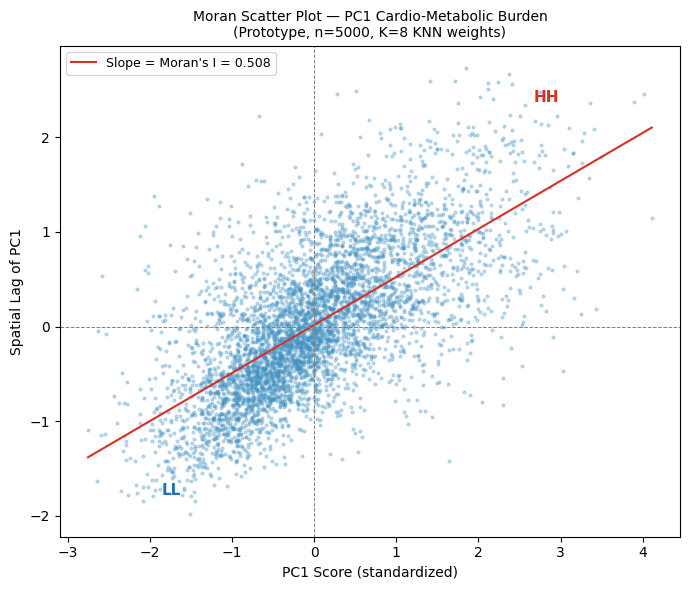

Moran scatter plot slope (0.5076) matches Moran's I (0.5076): PASSED


In [23]:
# ── Moran Scatter Plot (prototype) ───────────────────────────────────────────
# The Moran scatter plot visualizes the relationship between each observation's
# value and the spatial lag (weighted mean of neighbors).
# Positive slope → positive spatial autocorrelation.
# Quadrant labels: HH (upper-right), LL (lower-left) = spatial clusters;
#                  HL (upper-left), LH (lower-right) = spatial outliers.

from esda.moran import Moran_Local

# Standardize PC1 for scatter plot axes
pc1_std  = (pc1_proto - pc1_proto.mean()) / pc1_proto.std()
lag_pc1  = libpysal.weights.lag_spatial(w_proto, pc1_std)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(pc1_std, lag_pc1, s=4, alpha=0.3, color="#4393c3")

# Regression line (slope = Moran's I)
m, b = np.polyfit(pc1_std, lag_pc1, 1)
x_line = np.linspace(pc1_std.min(), pc1_std.max(), 100)
ax.plot(x_line, m * x_line + b, color="#d73027", linewidth=1.5,
        label=f"Slope = Moran's I = {mi_proto.I:.3f}")

ax.axhline(0, color="grey", linewidth=0.7, linestyle="--")
ax.axvline(0, color="grey", linewidth=0.7, linestyle="--")

# Quadrant labels
ax.text(ax.get_xlim()[1]*0.6, ax.get_ylim()[1]*0.8, "HH", fontsize=11,
        color="#d73027", fontweight="bold")
ax.text(ax.get_xlim()[0]*0.6, ax.get_ylim()[0]*0.8, "LL", fontsize=11,
        color="#2171b5", fontweight="bold")

ax.set_xlabel("PC1 Score (standardized)", fontsize=10)
ax.set_ylabel("Spatial Lag of PC1", fontsize=10)
ax.set_title("Moran Scatter Plot — PC1 Cardio-Metabolic Burden\n"
             f"(Prototype, n={PROTO_N}, K=8 KNN weights)", fontsize=10)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Test: regression slope should match Moran's I closely
assert abs(m - mi_proto.I) < 0.02, f"Slope {m:.4f} does not match Moran's I {mi_proto.I:.4f}"
print(f"Moran scatter plot slope ({m:.4f}) matches Moran's I ({mi_proto.I:.4f}): PASSED")

Significant LISA clusters (p < 0.05), n=5000 prototype:
  HH (High-High): 887 tracts (41.9% of significant)
  LH (Low-High): 150 tracts (7.1% of significant)
  LL (Low-Low): 1001 tracts (47.2% of significant)
  HL (High-Low): 81 tracts (3.8% of significant)

Total significant: 2,119 / 5,000 tracts (42.4%)


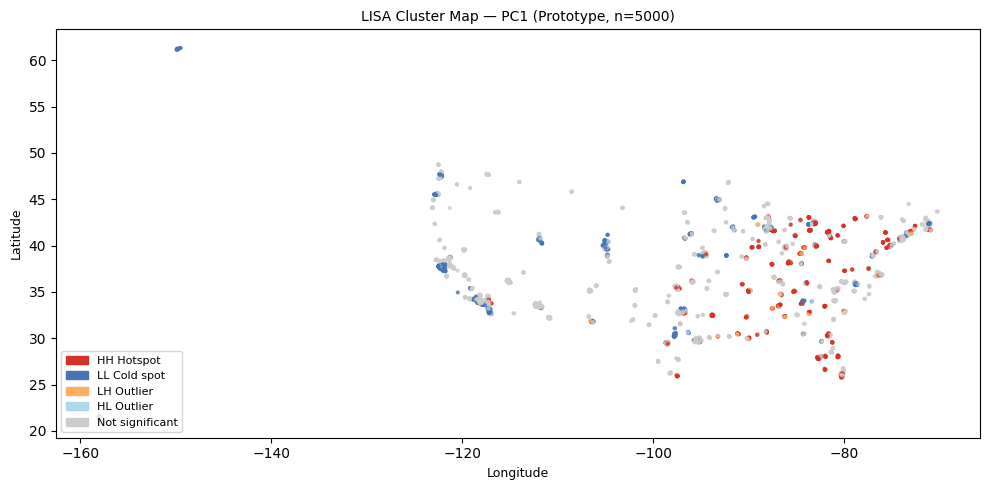

LISA feasibility test: PASSED


In [24]:
# ── Local Moran's I — LISA (prototype) ───────────────────────────────────────
# LISA identifies statistically significant local clusters and outliers.
# We run on the 5 K prototype to confirm the package works and visualize
# the cluster types before scaling to the full dataset.

lisa_proto = Moran_Local(pc1_proto, w_proto, permutations=999,
                          seed=RANDOM_STATE)

# LISA quadrant codes: 1=HH, 2=LH, 3=LL, 4=HL
# Significant at alpha=0.05
sig_mask  = lisa_proto.p_sim < 0.05
quadrants = lisa_proto.q   # 1–4 per tract

cluster_counts = pd.Series(quadrants[sig_mask]).value_counts().sort_index()
quad_names = {1: "HH (High-High)", 2: "LH (Low-High)",
               3: "LL (Low-Low)",   4: "HL (High-Low)"}

print(f"Significant LISA clusters (p < 0.05), n={PROTO_N} prototype:")
for q, cnt in cluster_counts.items():
    pct = cnt / sig_mask.sum() * 100
    print(f"  {quad_names.get(q, q)}: {cnt} tracts ({pct:.1f}% of significant)")

print(f"\nTotal significant: {sig_mask.sum():,} / {PROTO_N:,} tracts "
      f"({sig_mask.mean()*100:.1f}%)")

# Plot LISA cluster map (scatter-based, no shapefile needed)
colors_map = {
    (True, 1): "#d73027",   # HH — hot spot
    (True, 3): "#4575b4",   # LL — cold spot
    (True, 2): "#fdae61",   # LH
    (True, 4): "#abd9e9",   # HL
}

c_vals = [
    colors_map.get((bool(sig_mask[i]), quadrants[i]), "#cccccc")
    for i in range(PROTO_N)
]

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(proto_df["lon"], proto_df["lat"], c=c_vals, s=4, alpha=0.7)

# Legend
legend_patches = [
    mpatches.Patch(color="#d73027", label="HH Hotspot"),
    mpatches.Patch(color="#4575b4", label="LL Cold spot"),
    mpatches.Patch(color="#fdae61", label="LH Outlier"),
    mpatches.Patch(color="#abd9e9", label="HL Outlier"),
    mpatches.Patch(color="#cccccc", label="Not significant"),
]
ax.legend(handles=legend_patches, fontsize=8, loc="lower left")
ax.set_xlabel("Longitude", fontsize=9)
ax.set_ylabel("Latitude", fontsize=9)
ax.set_title(f"LISA Cluster Map — PC1 (Prototype, n={PROTO_N})", fontsize=10)
plt.tight_layout()
plt.show()

# Test: HH clusters should dominate over random (significant tracts > 5%)
assert sig_mask.mean() > 0.05, "Too few significant LISA tracts — unexpected for health data."
print("LISA feasibility test: PASSED")

In [25]:
# ── Moran's I sensitivity to K (spatial weights) ─────────────────────────────
# We test K ∈ {4, 8, 16} to confirm the spatial signal is robust to the
# choice of neighborhood size — a necessary feasibility check before committing
# to K=8 in Checkpoint 3.

print("Sensitivity analysis: Moran's I vs. number of KNN neighbors (K)\n")

K_VALS = [4, 8, 16]
moran_sensitivity_rows = []

for k_val in K_VALS:
    w_k = KNN.from_array(coords_proto, k=k_val)
    w_k.transform = "R"
    mi_k = Moran(pc1_proto, w_k, permutations=499)  # 499 permutations for speed
    moran_sensitivity_rows.append({
        "K": k_val,
        "Moran_I": round(mi_k.I, 4),
        "p_sim": round(mi_k.p_sim, 4),
        "z_norm": round(mi_k.z_norm, 3)
    })
    print(f"  K={k_val:2d} → I={mi_k.I:.4f}, p={mi_k.p_sim:.4f}, z={mi_k.z_norm:.2f}")

sens_df = pd.DataFrame(moran_sensitivity_rows).set_index("K")
print("\nMoran's I sensitivity table:")
display(sens_df)

# Test: Moran's I should remain significant across all K values
assert all(sens_df["p_sim"] < 0.05), (
    "Spatial autocorrelation not robust across K values — reconsider external method."
)
print("Spatial robustness test: PASSED — Moran's I is significant across all K values.")

Sensitivity analysis: Moran's I vs. number of KNN neighbors (K)

  K= 4 → I=0.5758, p=0.0020, z=61.72
  K= 8 → I=0.5076, p=0.0020, z=76.60
  K=16 → I=0.4364, p=0.0020, z=93.77

Moran's I sensitivity table:


,Moran_I,p_sim,z_norm
K,,,
4,0.5758,0.0020,61.7210
8,0.5076,0.0020,76.5980
16,0.4364,0.0020,93.7650


Spatial robustness test: PASSED — Moran's I is significant across all K values.


---
## Section 9: Method and Metric Plan Summary

In [26]:
plan_data = {
    "RQ": ["RQ1", "RQ1", "RQ2", "RQ2", "RQ3", "RQ3"],
    "Phase": ["Primary", "Validation", "Primary", "Sensitivity", "Primary", "Sensitivity"],
    "Algorithm": [
        "K-Means (k-means++, n_init=10)",
        "Agglomerative Hierarchical (Ward)",
        "Isolation Forest (n_est=200)",
        "Contamination sweep {0.01, 0.02, 0.05}",
        "Global + Local Moran's I (LISA)",
        "KNN K sweep {4, 8, 16}"
    ],
    "Input": [
        "X_pca (27K × 4)", "X_pca sample",
        "X_pca (27K × 4)", "X_pca (27K × 4)",
        "PC1 + KNN weights", "PC1 + KNN weights"
    ],
    "Primary Metric": [
        "Silhouette Score",
        "Dendrogram cut consistency",
        "Anomaly score distribution",
        "Set overlap across thresholds (%)",
        "Moran's I statistic + pseudo-p",
        "I stability across K values"
    ],
    "Secondary Metric": [
        "Davies–Bouldin, WCSS Elbow",
        "Cophenetic correlation",
        "State distribution of anomalies",
        "—",
        "LISA HH/LL fraction, z-scores",
        "—"
    ],
    "Baseline": [
        "Random cluster assignment",
        "—",
        "Top-decile raw PC1 (univariate)",
        "—",
        "I = 0 (spatial randomness)",
        "—"
    ]
}

plan_df = pd.DataFrame(plan_data)
print("=== Checkpoint 3 Methodological Plan ===")
display(plan_df.set_index(["RQ", "Phase"]))

=== Checkpoint 3 Methodological Plan ===


Algorithm              Input                     Primary Metric  \
RQ  Phase                                                                                                       
RQ1 Primary              K-Means (k-means++, n_init=10)    X_pca (27K × 4)                   Silhouette Score   
    Validation        Agglomerative Hierarchical (Ward)       X_pca sample         Dendrogram cut consistency   
RQ2 Primary                Isolation Forest (n_est=200)    X_pca (27K × 4)         Anomaly score distribution   
    Sensitivity  Contamination sweep {0.01, 0.02, 0.05}    X_pca (27K × 4)  Set overlap across thresholds (%)   
RQ3 Primary             Global + Local Moran's I (LISA)  PC1 + KNN weights     Moran's I statistic + pseudo-p   
    Sensitivity                  KNN K sweep {4, 8, 16}  PC1 + KNN weights        I stability across K values   

                                Secondary Metric                         Baseline  
RQ  Phase                                                                          
RQ1 Primary           Davies–Bouldin, WCSS Elbow        Random cluster assignment  
    Validation            Cophenetic correlation                                —  
RQ2 Primary      State distribution of anomalies  Top-decile raw PC1 (univariate)  
    Sensitivity                                —                                —  
RQ3 Primary        LISA HH/LL fraction, z-scores       I = 0 (spatial randomness)  
    Sensitivity                                —                                —

---
## Section 10: Summary and Outlook

### What This Checkpoint Established

| Finding | Actual Result | Implication for CP3 |
|---|---|---|
| PCA dimensionality | 4 PCs = 91.2% variance; PC1 loads on Stroke/CKD/Diabetes/BP/COPD | Clusters will be clinically labeled as cardio-metabolic burden profiles |
| Tract coverage | 26,968 / 27,648 (97.5%); 680 tracts lost to all-NaN pivot rows | Document drop; < 2.5% loss is acceptable |
| Optimal k (K-Means) | k = 2 (Sil=0.38, DB=1.04); k=4 also explored | CP3 reports k=2 as primary; k=4 as interpretability-motivated alternative |
| Isolation Forest | Anomalies concentrate at higher PC1 (mean 0.31 vs −0.01); 100% stability of 0.01 set within 0.02 set | Anomalies are multi-dimensional; CP3 will cross-tabulate with cluster labels |
| Coordinate coverage | 100% valid coordinates; lon [−158°, −70°], lat [21°, 61°] | No imputation needed; Moran's I feasible on all 26,968 tracts |
| Global Moran's I | I = 0.508, z = 76.6, p = 0.001 (prototype, n=5K) | Strong spatial autocorrelation expected on full dataset |
| LISA clusters | 42.4% of prototype tracts significant; HH 41.9%, LL 47.2% | CP3 will produce full-dataset LISA map with geographic hotspot identification |
| K sensitivity (Moran's) | I significant for K = 4, 8, 16 | K=8 chosen as primary; finding is robust |

### Central Research Story for Checkpoint 3

> **U.S. census tracts split primarily into two health burden profiles — high and low cardio-metabolic burden — with k=2 optimal across all metrics. A subset of tracts is multi-indicator anomalous (extreme in 4D PCA space, not just on one measure). Both the cluster structure and the anomalies show strong spatial concentration (Moran's I = 0.51, p < 0.001 even on a 5,000-tract prototype), pointing to persistent geographic health inequity rather than random individual-level variation. Moran's I and LISA are essential to characterize this spatial structure — course-only methods (K-Means, Isolation Forest) cannot answer the 'where' question.**


---
## Collaboration Declaration

```
On my honor, I declare the following resources:

1. Collaborators:
   - None

2. Web Sources:
   - https://data.cdc.gov/500-Cities-Places/500-Cities-Local-Data-for-Better-Health-2019-relea/6vp6-wxuq/about_data
     CDC 500 Cities dataset portal and documentation
   - https://dev.socrata.com/consumers/getting-started
     Socrata Open Data API (SODA) documentation for $limit/$offset paging
   - https://pysal.org/esda/
     PySAL ESDA documentation for Moran's I and LISA statistics
   - https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.IsolationForest.html
     scikit-learn Isolation Forest API reference
   - https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html
     scikit-learn KMeans API reference
   - https://scikit-learn.org/stable/modules/clustering.html#silhouette-coefficient
     scikit-learn Silhouette Coefficient documentation

3. AI Tools:
   - ChatGPT:
   Prompt 1: Here is my checkpoint 1 notebook. I selected the CDC 500 Cities dataset. Can you give me a quick recap of what I found and what the dataset looks like?
Prompt 2: Ok now help me set up the environment for checkpoint 2. Same dataset, same setup as before but clean.
Prompt 3: I need to form 3 research questions for this checkpoint. My dataset has health measures across census tracts. At least 2 should use things like clustering or anomaly detection and 1 needs to be something we didn't learn in class. What can I do?
Prompt 4: You mentioned spatial autocorrelation. What even is that? Like how is it different from just clustering the data normally?
Prompt 5: What is Moran's I exactly? Give me a simple explanation like I've never heard of it before.
Prompt 6: Ok so my PCA chart shows PC1 loads on stroke, diabetes, kidney disease and blood pressure. How do I explain what PC1 means in plain English for my write-up?
Prompt 7: My K-Means is giving best results at k=2. I thought there would be like 4 or 5 clusters. Did something go wrong or is k=2 fine?
Prompt 8: How do I actually run Isolation Forest in sklearn? What parameters should I set and what does the contamination parameter do?
Prompt 9: I ran Isolation Forest and the anomaly mean PC1 score is 0.31 vs 0.006 for normal tracts. Is that a big enough difference to say it's working?
Prompt 10: How do I build the spatial weights matrix from lat lon coordinates in Python? I have the libpysal library.
Prompt 11: What are the HH LL HL LH labels in the LISA map? What does each one mean for my health data specifically?

4. Citations:
     In SODA '07: Proceedings of the Eighteenth Annual ACM-SIAM Symposium.
   - Rey, S. J., & Anselin, L. (2010). PySAL: A Python Library of Spatial Analytical Methods.
     In Handbook of Applied Spatial Analysis (pp. 175–193). Springer.
```